In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/baseline-artifacts/thresholds.json
/kaggle/input/baseline-artifacts/df_resid.parquet
/kaggle/input/baseline-artifacts/df_pred.parquet
/kaggle/input/baseline-artifacts/df_wide.parquet
/kaggle/input/caf-dataset/CAF_sensors.dbf
/kaggle/input/caf-dataset/Hourly/Hourly/CAF141.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF019.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF209.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF007.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF397.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF237.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF205.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF125.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF139.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF095.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF201.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF215.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF079.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF231.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF275.

# Data and Preprocessing

In [2]:
# ================= CONFIG =================
SEED = 42
WINDOW = 24
K_NEIGHBORS = 4

import numpy as np
import pandas as pd
import torch
import random

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


In [3]:
# ================= DATA LOAD =================
df_wide = pd.read_parquet(
    "/kaggle/input/baseline-artifacts/df_wide.parquet"
)

df_wide = df_wide.sort_index()
sensor_ids = df_wide.columns.tolist()

T, N = df_wide.shape
print("Time steps:", T)
print("Sensors:", N)


Time steps: 66705
Sensors: 10


In [4]:
# ================= MISSING DATA =================
df_filled = df_wide.interpolate(limit_direction="both")
df_filled = df_filled.fillna(df_filled.mean())

assert not df_filled.isna().any().any(), "❌ NaNs still present"


In [5]:
# ================= NORMALIZATION =================
X_np = df_filled.values.astype(np.float32)

mean = X_np.mean()
std  = X_np.std() + 1e-6

X_np = (X_np - mean) / std
X = torch.tensor(X_np, dtype=torch.float32)

assert torch.isfinite(X).all(), "❌ Non-finite values"


In [6]:
# ================= SENSOR METADATA =================
import geopandas as gpd

DBF_PATH = "/kaggle/input/caf-dataset/CAF_sensors.dbf"
gdf = gpd.read_file(DBF_PATH)

sensor_meta = gdf[["Location", "Easting", "Northing"]].copy()

coords = (
    sensor_meta
    .set_index("Location")
    .loc[sensor_ids][["Easting", "Northing"]]
    .values
)

assert coords.shape == (N, 2)


In [7]:
# ================= SPATIAL GRAPH =================
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1).fit(coords)
distances, indices = nbrs.kneighbors(coords)

# Remove self-loops (first neighbor)
neighbors = indices[:, 1:]
neighbor_dist = distances[:, 1:]


In [8]:
# ================= DISTANCE-WEIGHTED ADJ =================
A = np.zeros((N, N), dtype=np.float32)

for i in range(N):
    for j, d in zip(neighbors[i], neighbor_dist[i]):
        A[i, j] = 1.0 / (d + 1e-6)
        A[j, i] = A[i, j]

# self-loops
np.fill_diagonal(A, 1.0)

# row-normalize
A = A / A.sum(axis=1, keepdims=True)

A = torch.tensor(A, dtype=torch.float32)

assert torch.allclose(A.sum(dim=1), torch.ones(N)), "❌ Bad normalization"


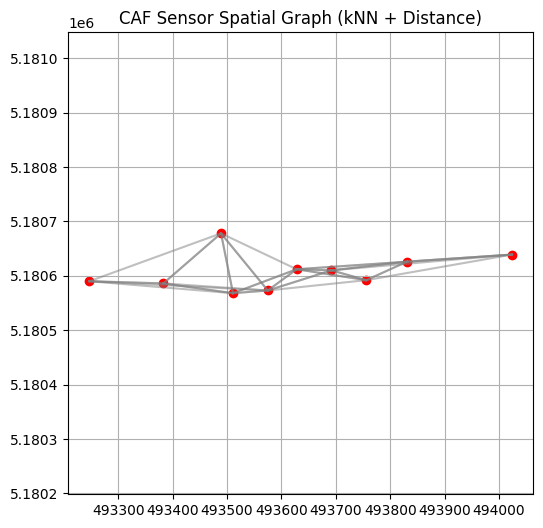

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], c="red")

for i in range(N):
    for j in neighbors[i]:
        plt.plot(
            [coords[i,0], coords[j,0]],
            [coords[i,1], coords[j,1]],
            color="gray", alpha=0.5
        )

plt.title("CAF Sensor Spatial Graph (kNN + Distance)")
plt.axis("equal")
plt.grid(True)
plt.show()


# Fault Injection

In [10]:
# ================= FAULT CONFIG =================
FAULT_SENSOR = 2
FAULT_START  = 20000
FAULT_END    = 20500
FAULT_MAG    = 5.0   # in normalized units


In [11]:
# ================= FAULT GROUND TRUTH =================
T, N = X.shape

fault_gt = torch.zeros((T, N), dtype=torch.bool)
fault_gt[FAULT_START:FAULT_END, FAULT_SENSOR] = True

print("Total faulted samples:", fault_gt.sum().item())


Total faulted samples: 500


In [12]:
# ================= FAULT INJECTION =================
X_fault = X.clone()
X_fault[FAULT_START:FAULT_END, FAULT_SENSOR] += FAULT_MAG

assert torch.isfinite(X_fault).all()


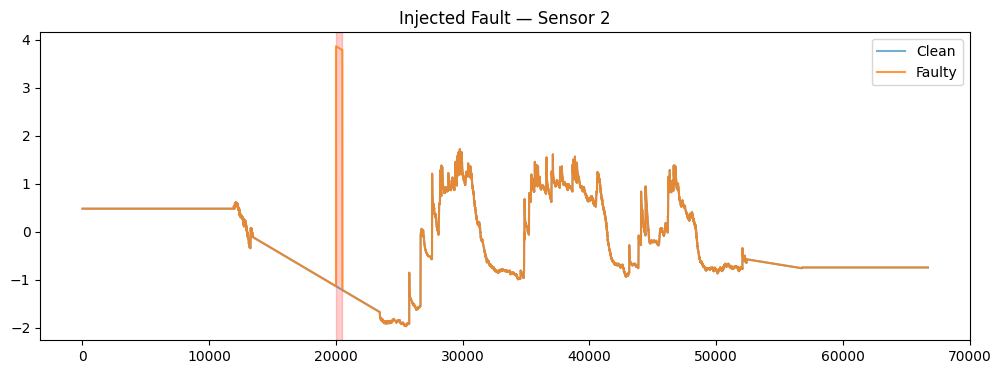

In [13]:
import matplotlib.pyplot as plt

s = FAULT_SENSOR

plt.figure(figsize=(12,4))
plt.plot(X[:, s].cpu(), label="Clean", alpha=0.6)
plt.plot(X_fault[:, s].cpu(), label="Faulty", alpha=0.8)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title(f"Injected Fault — Sensor {s}")
plt.show()


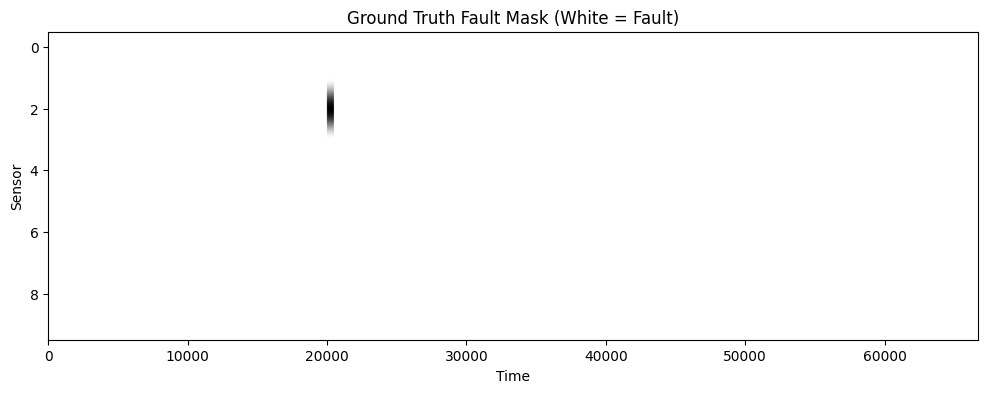

In [14]:
plt.figure(figsize=(12,4))
plt.imshow(
    fault_gt.T.cpu(),
    aspect="auto",
    cmap="gray_r"
)
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Ground Truth Fault Mask (White = Fault)")
plt.show()


In [15]:
# ================= SPATIAL BASELINE PREDICTOR =================
A_np = A.cpu().numpy()

def spatial_predictor(X, A):
    """
    X: (T, N)
    A: (N, N) adjacency (row-normalized)
    """
    return X @ A.T


In [16]:
# ================= PREDICTIONS & RESIDUALS =================
pred_spatial = spatial_predictor(X_fault, A)

residuals = torch.abs(X_fault - pred_spatial)
res_np = residuals.cpu().numpy()


In [17]:
assert residuals.shape == X.shape


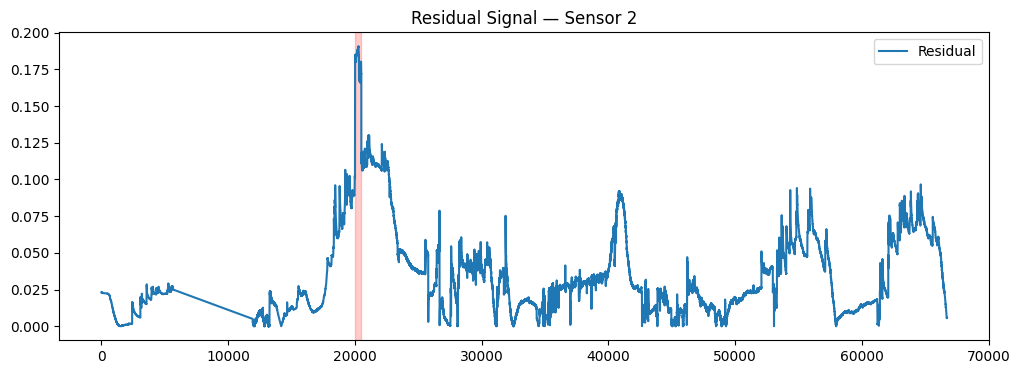

In [18]:
s = FAULT_SENSOR

plt.figure(figsize=(12,4))
plt.plot(res_np[:, s], label="Residual")
plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title(f"Residual Signal — Sensor {s}")
plt.show()


In [19]:
# ================= ROBUST THRESHOLDS =================
res_np = residuals.cpu().numpy()

median = np.nanmedian(res_np, axis=0)
mad = np.nanmedian(np.abs(res_np - median), axis=0)

THRESH = median + 4.0 * mad   # conservative


In [20]:
# ================= RAW FAULT FLAGS =================
fault_flags_raw = res_np > THRESH


In [21]:
# ================= PERSISTENCE FILTER =================
W = 100   # window length
K = 60    # minimum positives

fault_flags = np.zeros_like(fault_flags_raw, dtype=bool)

for s in range(fault_flags_raw.shape[1]):
    conv = np.convolve(
        fault_flags_raw[:, s].astype(int),
        np.ones(W, dtype=int),
        mode="same"
    )
    fault_flags[:, s] = conv >= K


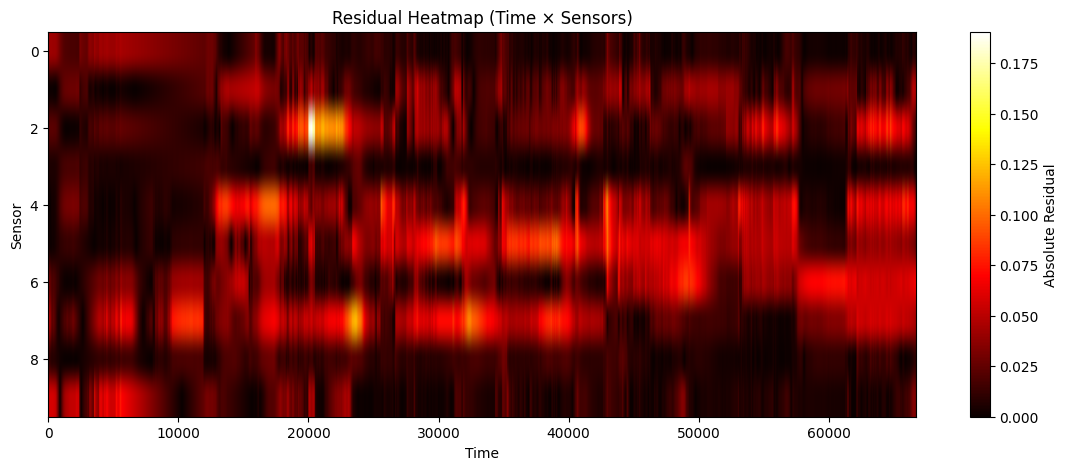

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.imshow(
    res_np.T,
    aspect="auto",
    cmap="hot"
)
plt.colorbar(label="Absolute Residual")
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Residual Heatmap (Time × Sensors)")
plt.show()


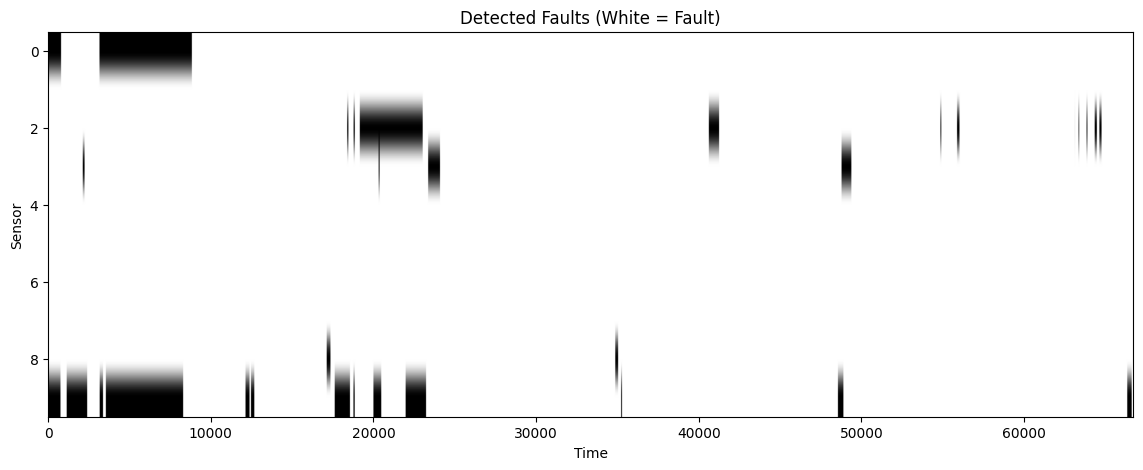

In [23]:
plt.figure(figsize=(14,5))
plt.imshow(
    fault_flags.T,
    aspect="auto",
    cmap="gray_r"
)
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Detected Faults (White = Fault)")
plt.show()


In [24]:
# ================= EVALUATION =================
gt = fault_gt.cpu().numpy()

TP = np.logical_and(fault_flags, gt).sum()
FP = np.logical_and(fault_flags, ~gt).sum()
FN = np.logical_and(~fault_flags, gt).sum()

precision = TP / (TP + FP + 1e-6)
recall    = TP / (TP + FN + 1e-6)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")


Precision: 0.020
Recall:    1.000


In [25]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [26]:
# ========= GLOBAL CONFIG =========
sensor_idx = 2
W = 24
t_start = 20000
t_end = 20500
# ================================



# Temporal Only

In [27]:
class TemporalDataset(Dataset):
    def __init__(self, series, window):
        self.series = series
        self.window = window

    def __len__(self):
        return len(self.series) - self.window

    def __getitem__(self, i):
        x = self.series[i:i+self.window]
        y = self.series[i+self.window]
        return x.unsqueeze(-1), y


In [28]:
# ================= CLEAN & FAULT DATA =================

# Clean (normalized, no fault)
X_clean = X.clone()          # X was your normalized df_filled tensor

# Faulty (normalized, injected fault)
X_fault = X_fault.clone()    # from inject_bias(...)


In [29]:
print(X_clean.shape, X_fault.shape)
assert X_clean.shape == X_fault.shape


torch.Size([66705, 10]) torch.Size([66705, 10])


In [30]:
train_ds = TemporalDataset(X_clean[:, sensor_idx], W)
test_ds  = TemporalDataset(X_fault[:, sensor_idx], W)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)


In [31]:
class TemporalGRU(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.gru = nn.GRU(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h.squeeze(0)).squeeze(-1)


In [32]:
model = TemporalGRU()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


In [33]:
for epoch in range(20):
    total = 0
    for x, y in train_loader:
        pred = model(x)
        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print(f"Epoch {epoch+1}: {total/len(train_loader):.6f}")


Epoch 1: 0.016032
Epoch 2: 0.000284
Epoch 3: 0.000232
Epoch 4: 0.000201
Epoch 5: 0.000175
Epoch 6: 0.000155
Epoch 7: 0.000139
Epoch 8: 0.000131
Epoch 9: 0.000121
Epoch 10: 0.000116
Epoch 11: 0.000113
Epoch 12: 0.000106
Epoch 13: 0.000104
Epoch 14: 0.000105
Epoch 15: 0.000099
Epoch 16: 0.000099
Epoch 17: 0.000101
Epoch 18: 0.000100
Epoch 19: 0.000100
Epoch 20: 0.000100


In [34]:
model.eval()
preds = []

with torch.no_grad():
    for x, _ in test_loader:
        preds.append(model(x))

preds = torch.cat(preds)


In [35]:
# ================= TEMPORAL RECONSTRUCTION (CORRECT) =================

T, N = X_fault.shape
X_temp_hat = X_fault.clone()   # fallback is faulty signal

# preds shape: (T-W,) for single sensor
X_temp_hat[W:, sensor_idx] = preds.squeeze()

# sanity checks
assert X_temp_hat.shape == X_fault.shape
assert not torch.isnan(X_temp_hat).any()


In [36]:
true_clean = X_clean[W:, sensor_idx]
faulty_obs = X_fault[W:, sensor_idx]

rmse_faulty = torch.sqrt(((faulty_obs - true_clean)**2).mean())
rmse_temp   = torch.sqrt(((preds - true_clean)**2).mean())

print("RMSE faulty:", rmse_faulty.item())
print("RMSE temporal:", rmse_temp.item())


RMSE faulty: 0.4329661726951599
RMSE temporal: 0.3962700366973877


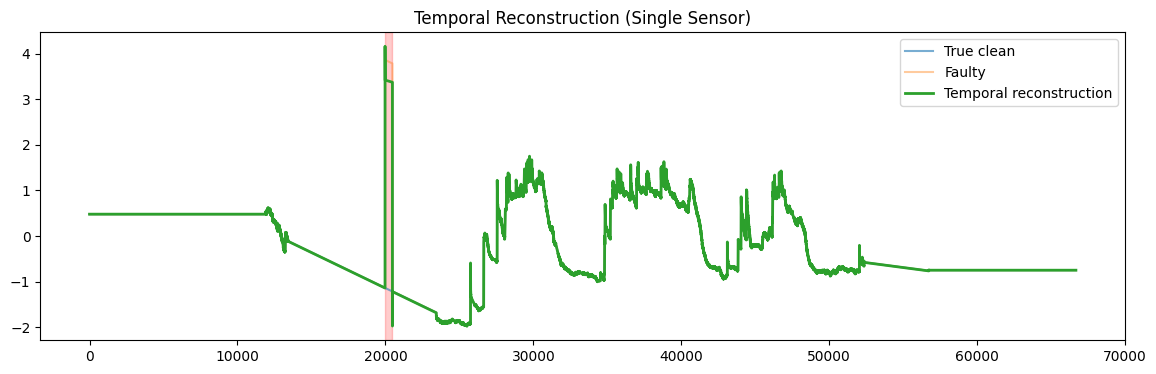

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(true_clean, label="True clean", alpha=0.6)
plt.plot(faulty_obs, label="Faulty", alpha=0.4)
plt.plot(preds, label="Temporal reconstruction", linewidth=2)

plt.axvspan(t_start-W, t_end-W, color="red", alpha=0.2)
plt.legend()
plt.title("Temporal Reconstruction (Single Sensor)")
plt.show()


In [38]:
# ================= FAULT WINDOW MASK =================
mask_fault_window = torch.zeros(T, dtype=torch.bool)
mask_fault_window[FAULT_START:FAULT_END] = True

assert mask_fault_window.shape[0] == T


In [39]:
# ================= GROUND TRUTH =================
Y_true = X_clean

assert Y_true.shape == X_fault.shape


In [40]:
rmse_temporal_fault_window = torch.sqrt(
    torch.mean(
        (X_temp_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


# Spatial Only

In [41]:
import numpy as np

N = coords.shape[0]

# Pairwise distances
dist = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)

# Avoid self-edges
np.fill_diagonal(dist, np.inf)

# Hyperparameters
K = 4            # number of neighbors
eps = 1e-6       # numerical stability

# Nearest neighbors per sensor
nbr_idx = np.argsort(dist, axis=1)[:, :K]   # (N, K)
nbr_dist = np.take_along_axis(dist, nbr_idx, axis=1)

# Inverse-distance weights
W_spatial = 1.0 / (nbr_dist + eps)
W_spatial = W_spatial / W_spatial.sum(axis=1, keepdims=True)


In [42]:
def spatial_reconstruct(X_obs, fault_flags, nbr_idx, W_spatial):
    """
    X_obs:        (T, N) observed (faulty) data
    fault_flags:  (T, N) boolean
    Returns:
        X_spatial_hat: (T, N)
    """
    T, N = X_obs.shape
    X_hat = X_obs.copy()

    for t in range(T):
        for s in range(N):
            if fault_flags[t, s]:
                neighbors = nbr_idx[s]
                weights = W_spatial[s]

                X_hat[t, s] = np.sum(
                    weights * X_obs[t, neighbors]
                )

    return X_hat


In [43]:
X_spatial_hat = spatial_reconstruct(
    X_fault.numpy(),
    fault_flags,
    nbr_idx,
    W_spatial
)

X_spatial_hat = torch.tensor(X_spatial_hat, dtype=torch.float32)


In [44]:
# True clean reference
Y_true = X_clean

# RMSE over full signal
rmse_spatial = torch.sqrt(
    torch.mean((X_spatial_hat - Y_true) ** 2)
)

print("RMSE spatial-only:", rmse_spatial.item())


RMSE spatial-only: 0.2994402050971985


In [45]:
mask_fault_window = torch.zeros(Y_true.shape[0], dtype=torch.bool)
mask_fault_window[t_start:t_end] = True

rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_faulty_fault_window = torch.sqrt(
    torch.mean(
        (X_fault[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE faulty (fault window):", rmse_faulty_fault_window.item())
print("RMSE spatial (fault window):", rmse_spatial_fault_window.item())


RMSE faulty (fault window): 5.0
RMSE spatial (fault window): 1.7880803346633911


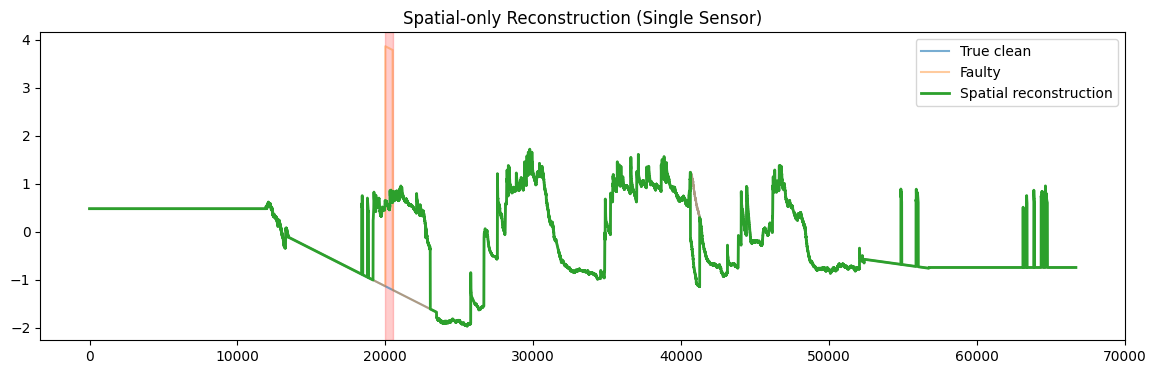

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_fault[:, sensor_idx], label="Faulty", alpha=0.4)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial reconstruction", linewidth=2)

plt.axvspan(t_start, t_end, color="red", alpha=0.2)
plt.legend()
plt.title("Spatial-only Reconstruction (Single Sensor)")
plt.show()


In [47]:
rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


# Rule-based Temporal + Spatial

In [48]:
def compute_trust_weights(fault_len, max_len=200):
    """
    fault_len: how long the current fault has lasted
    """
    # Temporal trust decays with fault duration
    alpha_temp = np.exp(-fault_len / max_len)
    alpha_spatial = 1.0 - alpha_temp
    return alpha_temp, alpha_spatial


In [49]:
def fuse_reconstruction(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    fault_duration = np.zeros(N, dtype=int)

    for t in range(T):
        for s in range(N):
            if fault_flags[t, s]:
                fault_duration[s] += 1

                a_t, a_s = compute_trust_weights(fault_duration[s])
                X_fused[t, s] = (
                    a_t * X_temp_hat[t, s]
                    + a_s * X_spatial_hat[t, s]
                )
            else:
                fault_duration[s] = 0

    return X_fused


In [50]:
X_fused = fuse_reconstruction(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags
)


In [51]:
rmse_fused_fault_window = torch.sqrt(
    torch.mean(
        (X_fused[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


In [52]:
print("RMSE temporal (fault window):", rmse_temporal_fault_window.item())
print("RMSE spatial  (fault window):", rmse_spatial_fault_window.item())
print("RMSE fused    (fault window):", rmse_fused_fault_window.item())


RMSE temporal (fault window): 4.570087432861328
RMSE spatial  (fault window): 1.7880803346633911
RMSE fused    (fault window): 1.8040648698806763


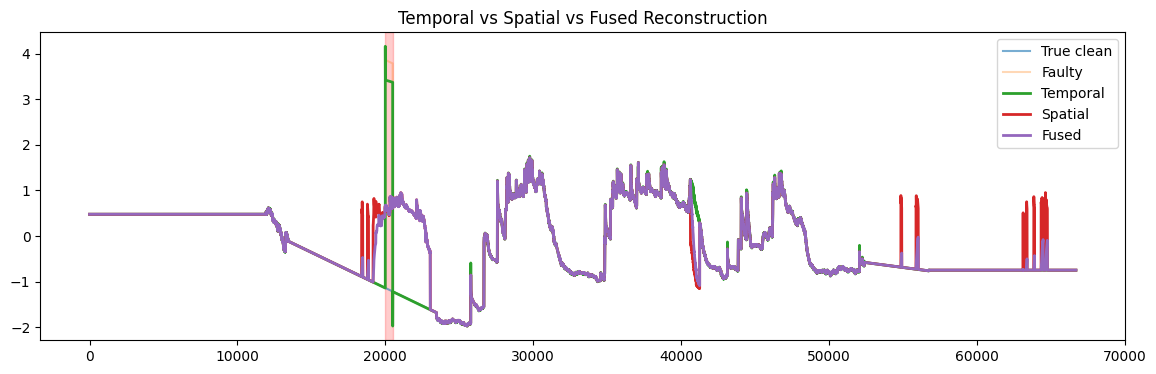

In [53]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_fault[:, sensor_idx], label="Faulty", alpha=0.3)
plt.plot(X_temp_hat[:, sensor_idx], label="Temporal", linewidth=2)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial", linewidth=2)
plt.plot(X_fused[:, sensor_idx], label="Fused", linewidth=2)

plt.axvspan(t_start, t_end, color="red", alpha=0.2)
plt.legend()
plt.title("Temporal vs Spatial vs Fused Reconstruction")
plt.show()


# Trust-Weighted Fusion

In [54]:
A_bin = (A > 0).float()
neighbors = {
    i: torch.where(A_bin[i])[0]
    for i in range(A.shape[0])
}

In [55]:
def deterministic_trust_fusion_v5(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags,
    neighbors,
    eps=1e-6
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    for t in range(T):
        for i in range(N):

            if not fault_flags[t, i]:
                continue

            e_temp = torch.abs(X_temp_hat[t, i] - X_spatial_hat[t, i])

            nbrs = neighbors[i]
            if len(nbrs) > 0:
                e_spat = torch.mean(
                    torch.abs(
                        X_spatial_hat[t, i]
                        - X_spatial_hat[t, nbrs]
                    )
                )
            else:
                e_spat = torch.tensor(1.0, device=X_fault.device)

            # 🔒 HARD GATE
            if e_temp > 2.0 * e_spat:
                X_fused[t, i] = X_spatial_hat[t, i]
                continue

            # ratio-based trust
            ratio = e_temp / (e_spat + eps)

            w_temp = torch.exp(-ratio)
            w_spat = torch.tensor(1.0, device=X_fault.device)

            Z = w_temp + w_spat
            w_temp /= Z
            w_spat /= Z

            X_fused[t, i] = (
                w_temp * X_temp_hat[t, i]
                + w_spat * X_spatial_hat[t, i]
            )

    return X_fused


In [56]:
X_fused = deterministic_trust_fusion_v5(
    X_fault,
    X_temp_hat,        # ✅ NOT X_temp_hat_aligned
    X_spatial_hat,
    fault_flags,
    neighbors
)


In [57]:
assert X_temp_hat.shape == X_fault.shape
assert X_spatial_hat.shape == X_fault.shape
assert X_fused.shape == X_fault.shape


In [58]:
# ================= TRUST SCORES (SAFE, SELF-CONTAINED) =================
eps = 1e-6

diff = torch.abs(X_fault - X_temp_hat)
scale = torch.median(diff, dim=0).values + eps

trust = torch.exp(-diff / scale)
trust = torch.clamp(trust, min=1e-6, max=1.0)

assert trust.shape == X_fault.shape
assert torch.isfinite(trust).all()

print(
    "trust stats →",
    "min:", trust.min().item(),
    "max:", trust.max().item(),
    "mean:", trust.mean().item()
)


trust stats → min: 9.999999974752427e-07 max: 1.0 mean: 0.9326907396316528


In [59]:
rmse_temporal_fault_window = torch.sqrt(
    torch.mean(
        (X_temp_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_fused_fault_window = torch.sqrt(
    torch.mean(
        (X_fused[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE temporal (fault window):", rmse_temporal_fault_window.item())
print("RMSE spatial  (fault window):", rmse_spatial_fault_window.item())
print("RMSE fused    (fault window):", rmse_fused_fault_window.item())


RMSE temporal (fault window): 4.570087432861328
RMSE spatial  (fault window): 1.7880803346633911
RMSE fused    (fault window): 1.7880803346633911


# Fault Recovery Dynamics

In [60]:
fault_flags_t = torch.from_numpy(fault_flags).bool()


In [61]:
recovery_start = torch.zeros((T, N), dtype=torch.bool)

for i in range(N):
    for t in range(1, T):
        recovery_start[t, i] = (
            fault_flags_t[t-1, i] &
            (~fault_flags_t[t, i])
        )


In [62]:
recovery_age = torch.zeros((T, N), dtype=torch.long)

for i in range(N):
    for t in range(1, T):

        if recovery_start[t, i]:
            recovery_age[t, i] = 1

        elif recovery_age[t-1, i] > 0 and not fault_flags_t[t, i]:
            recovery_age[t, i] = recovery_age[t-1, i] + 1

        else:
            recovery_age[t, i] = 0


In [63]:
RECOVERY_HORIZON = 24   # e.g. 1 day if hourly


In [64]:
def recovery_aware_fusion(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    fault_flags,
    recovery_age,
    recovery_horizon=24,
    eps=1e-6
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    for t in range(T):
        for i in range(N):

            # ---------- FAULT ----------
            if fault_flags[t, i]:
                X_fused[t, i] = X_spatial_hat[t, i]
                continue

            # ---------- RECOVERY ----------
            if recovery_age[t, i] > 0:

                # normalized recovery progress
                p = min(recovery_age[t, i] / recovery_horizon, 1.0)

                # disagreements
                e_temp = torch.abs(
                    X_temp_hat[t, i] - X_spatial_hat[t, i]
                )
                e_sensor = torch.abs(
                    X_fault[t, i] - X_spatial_hat[t, i]
                )

                # trust gates
                trust_temp = torch.exp(-e_temp)
                trust_sensor = torch.exp(-e_sensor)

                # hard safety: if sensor unstable → ignore it
                if e_sensor > 2.0 * e_temp:
                    trust_sensor = torch.tensor(0.0)

                # base weights
                w_spatial = 0.4                 # anchor
                w_temp    = 0.4 * p * trust_temp
                w_sensor  = 0.2 * p * trust_sensor

                # normalize
                Z = w_spatial + w_temp + w_sensor + eps
                w_spatial /= Z
                w_temp    /= Z
                w_sensor  /= Z

                X_fused[t, i] = (
                    w_spatial * X_spatial_hat[t, i]
                    + w_temp    * X_temp_hat[t, i]
                    + w_sensor  * X_fault[t, i]
                    
                )

            # ---------- HEALTHY ----------
            else:
                X_fused[t, i] = X_fault[t, i]

    return X_fused


In [65]:
X_fused_recovery = recovery_aware_fusion(
    X_fault,
    X_temp_hat,          # ✅ correct variable
    X_spatial_hat,
    fault_flags_t,
    recovery_age,
    RECOVERY_HORIZON
)


In [66]:
recovery_mask = (
    (recovery_age[:, sensor_idx] > 0) &
    (recovery_age[:, sensor_idx] <= RECOVERY_HORIZON)
)

rmse_recovery = torch.sqrt(
    torch.mean(
        (X_fused_recovery[recovery_mask, sensor_idx]
         - Y_true[recovery_mask, sensor_idx]) ** 2
    )
)

rmse_spatial_recovery = torch.sqrt(
    torch.mean(
        (X_spatial_hat[recovery_mask, sensor_idx]
         - Y_true[recovery_mask, sensor_idx]) ** 2
    )
)

print("RMSE recovery (fused):", rmse_recovery.item())
print("RMSE recovery (spatial):", rmse_spatial_recovery.item())


RMSE recovery (fused): 0.0012060145381838083
RMSE recovery (spatial): 0.0


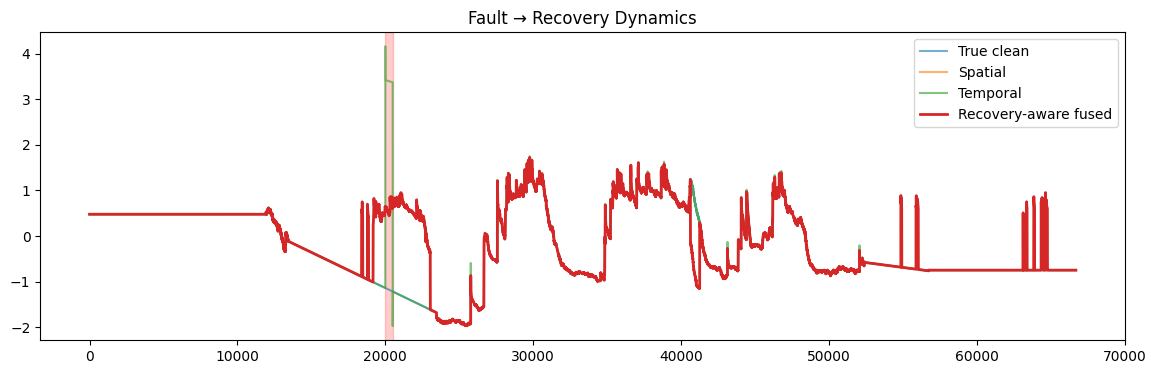

In [67]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial", alpha=0.6)
plt.plot(X_temp_hat[:, sensor_idx], label="Temporal", alpha=0.6)
plt.plot(X_fused_recovery[:, sensor_idx], label="Recovery-aware fused", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Fault → Recovery Dynamics")
plt.show()


# Trust-Weighted Spatial Centroid

In [68]:
def compute_trust_scores(X_obs, X_temp_hat, eps=1e-6):
    """
    X_obs:       (T, N) observed (possibly faulty)
    X_temp_hat:  (T, N) temporal predictions
    Returns:
        trust: (T, N) in (0, 1]
    """
    diff = torch.abs(X_obs - X_temp_hat)

    # per-sensor scale (robust)
    scale = torch.median(diff, dim=0).values + eps

    trust = torch.exp(-diff / scale)
    return trust


In [69]:
# ================= TRUST SCORES =================
trust = compute_trust_scores(
    X_fault,
    X_temp_hat
)

trust = torch.exp(-diff / scale)

# numerical safety floor
trust = torch.clamp(trust, min=1e-6, max=1.0)

assert trust.shape == X_fault.shape
assert torch.isfinite(trust).all()



In [70]:
def spatial_reconstruct_trust_weighted(
    X_obs,
    fault_flags,
    nbr_idx,
    nbr_dist,
    trust,
    eps=1e-6
):
    T, N = X_obs.shape
    X_hat = X_obs.clone()

    inv_dist = 1.0 / (nbr_dist + eps)  # (N, K)

    for t in range(T):
        for s in range(N):

            if not fault_flags[t, s]:
                continue  # healthy sensor → keep original

            nbrs = nbr_idx[s]      # (K,)
            geo_w = inv_dist[s]    # (K,)

            # 🔴 THIS IS THE KEY PART 🔴
            if fault_flags[t, s]:
                # use learned trust during fault
                trust_w = trust[t, nbrs]            # (K,)
            else:
                # uniform trust when healthy
                trust_w = torch.ones_like(geo_w)

            w = geo_w * trust_w
            w = w / (w.sum() + eps)

            X_hat[t, s] = torch.sum(
                w * X_obs[t, nbrs]
            )

    return X_hat


In [71]:
# ================= CONVERT NEIGHBORS TO TORCH =================
nbr_idx_torch = torch.tensor(nbr_idx, dtype=torch.long)
nbr_dist_torch = torch.tensor(nbr_dist, dtype=torch.float32)

assert nbr_idx_torch.shape == nbr_dist_torch.shape


In [72]:
X_spatial_hat_trust = spatial_reconstruct_trust_weighted(
    X_fault,
    fault_flags_t,
    nbr_idx_torch,
    nbr_dist_torch,
    trust
)


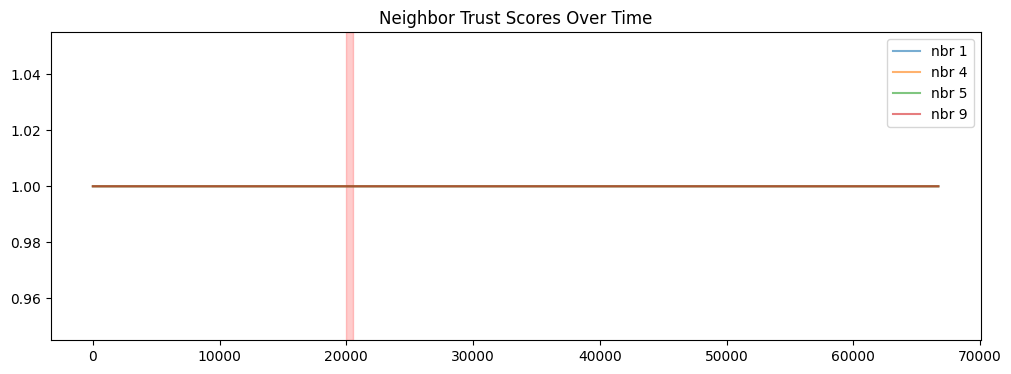

In [73]:
plt.figure(figsize=(12,4))
for n in nbr_idx[sensor_idx]:
    plt.plot(trust[:, n].cpu(), alpha=0.6, label=f"nbr {n}")

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.title("Neighbor Trust Scores Over Time")
plt.legend()
plt.show()


In [74]:
rmse_spatial_plain = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_spatial_trust = torch.sqrt(
    torch.mean(
        (X_spatial_hat_trust[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE spatial (distance only):", rmse_spatial_plain.item())
print("RMSE spatial (trust-weighted):", rmse_spatial_trust.item())


RMSE spatial (distance only): 1.7880803346633911
RMSE spatial (trust-weighted): 1.7880672216415405


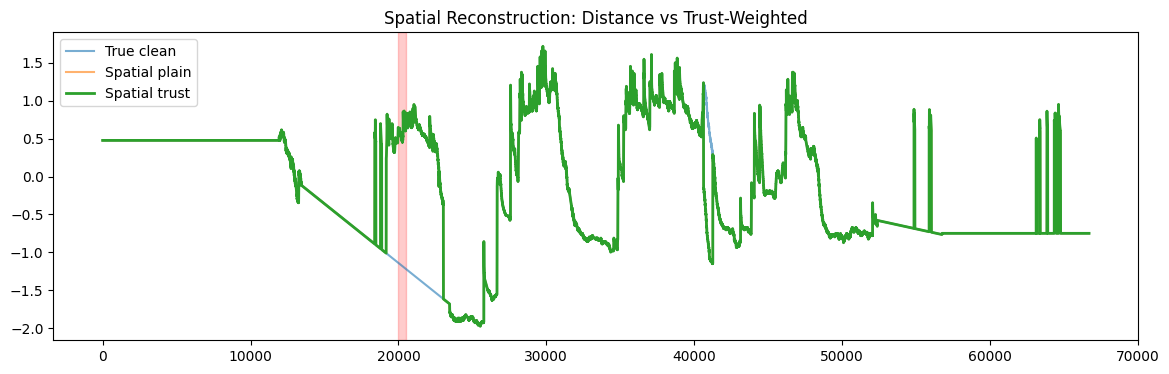

In [75]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial plain", alpha=0.6)
plt.plot(X_spatial_hat_trust[:, sensor_idx], label="Spatial trust", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Spatial Reconstruction: Distance vs Trust-Weighted")
plt.show()


# Inject a Faulty Neighbor (Controlled Stress Test)

In [146]:
# =========================================================
# MULTI-NEIGHBOR SIMULTANEOUS FAULT INJECTION
# =========================================================

target = sensor_idx
neighbors_target = nbr_idx[target]   # (K,)

# ---- CONFIG ----
NUM_FAULTY_NEIGHBORS = 2   # try 2, then 3
NEIGHBOR_FAULT_MAG = 5.0

# select which neighbors fail (closest ones, worst case)
faulty_neighbors = neighbors_target[:NUM_FAULTY_NEIGHBORS]

print("Target sensor:", target)
print("Faulty neighbors:", faulty_neighbors.tolist())

# ---- inject faults ----
X_fault_nb = X_fault.clone()

for n in faulty_neighbors:
    X_fault_nb[FAULT_START:FAULT_END, n] += NEIGHBOR_FAULT_MAG

assert torch.isfinite(X_fault_nb).all()


Target sensor: 2
Faulty neighbors: [1, 4]


In [147]:
# ================= TRUST (WITH FAULTY NEIGHBOR) =================
diff = torch.abs(X_fault_nb - X_temp_hat)
scale = torch.median(diff, dim=0).values + 1e-6

trust_nb = torch.exp(-diff / scale)
trust_nb = torch.clamp(trust_nb, min=1e-6, max=1.0)

print(
    "trust stats (neighbor-fault case) →",
    trust_nb.min().item(),
    trust_nb.mean().item()
)


trust stats (neighbor-fault case) → 9.999999974752427e-07 0.931191623210907


In [148]:
X_spatial_plain_nb = spatial_reconstruct(
    X_fault_nb.numpy(),
    fault_flags,
    nbr_idx,
    W_spatial
)
X_spatial_plain_nb = torch.tensor(X_spatial_plain_nb, dtype=torch.float32)


In [149]:
X_spatial_trust_nb = spatial_reconstruct_trust_weighted(
    X_fault_nb,
    fault_flags_t,
    nbr_idx_torch,
    nbr_dist_torch,
    trust_nb
)


In [150]:
rmse_plain_nb = torch.sqrt(
    torch.mean(
        (X_spatial_plain_nb[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_trust_nb = torch.sqrt(
    torch.mean(
        (X_spatial_trust_nb[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE spatial (distance-only, neighbor faulty):", rmse_plain_nb.item())
print("RMSE spatial (trust-weighted, neighbor faulty):", rmse_trust_nb.item())


RMSE spatial (distance-only, neighbor faulty): 5.109747409820557
RMSE spatial (trust-weighted, neighbor faulty): 1.3844287395477295


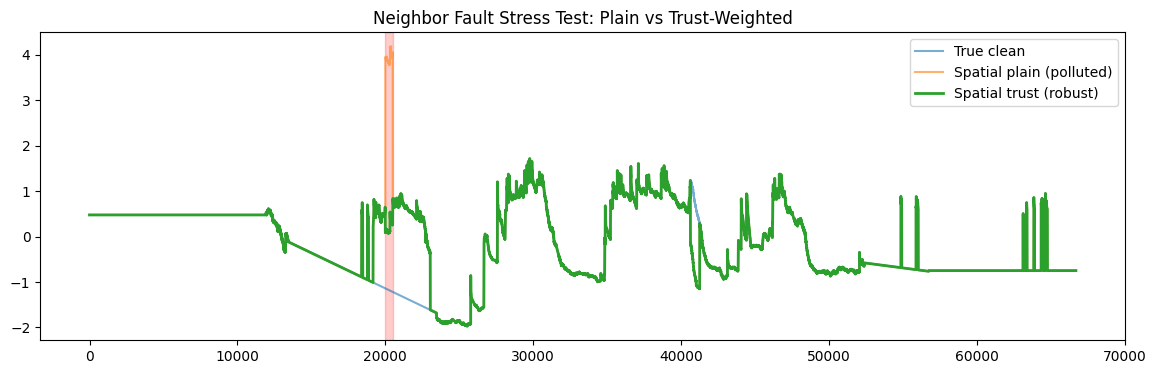

In [151]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_plain_nb[:, sensor_idx], label="Spatial plain (polluted)", alpha=0.6)
plt.plot(X_spatial_trust_nb[:, sensor_idx], label="Spatial trust (robust)", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Neighbor Fault Stress Test: Plain vs Trust-Weighted")
plt.show()


In [152]:
# average trust during fault window
avg_trust_fault = trust_nb[mask_fault_window].mean(dim=0)

for n in nbr_idx[sensor_idx]:
    print(f"Neighbor {n}: avg trust = {avg_trust_fault[n].item():.3f}")


Neighbor 1: avg trust = 0.000
Neighbor 4: avg trust = 0.000
Neighbor 5: avg trust = 1.000
Neighbor 9: avg trust = 1.000


In [153]:
for n in faulty_neighbors:
    delta = (
        X_fault_nb[FAULT_START:FAULT_END, n]
        - X_fault[FAULT_START:FAULT_END, n]
    ).mean()
    print(f"Injected delta for neighbor {n}: {delta.item():.2f}")


Injected delta for neighbor 1: 5.00
Injected delta for neighbor 4: 5.00


# Trust via RL

In [168]:
class NeighborFaultClassifier(nn.Module):
    def __init__(self, state_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # logits
        )

    def forward(self, state):
        return torch.sigmoid(self.net(state))  # P(neighbor faulty)


In [169]:
class TrustPolicy(nn.Module):
    def __init__(self, state_dim=4):   # ✅ was 5
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, state):
        return self.net(state)


In [170]:
def build_trust_state(
    X_obs,
    X_temp_hat,
    X_spatial_hat,
    fault_flags,
    nbr_idx_torch
):
    T, N = X_obs.shape
    state = torch.zeros((T, N, 4), device=X_obs.device)

    # 1. temporal disagreement
    state[..., 0] = torch.abs(X_obs - X_temp_hat)

    # 2. spatial disagreement
    for i in range(N):
        nbrs = nbr_idx_torch[i]
        state[:, i, 1] = torch.mean(
            torch.abs(X_obs[:, i].unsqueeze(1) - X_obs[:, nbrs]),
            dim=1
        )

    # 3. neighbor dispersion
    for i in range(N):
        nbrs = nbr_idx_torch[i]
        state[:, i, 2] = torch.std(X_obs[:, nbrs], dim=1)

    # 4. fault flag
    state[..., 3] = fault_flags.float()

    return state


In [171]:
def build_neighbor_state(
    t,
    target,
    X_obs,
    X_temp_hat,
    fault_flags,
    nbr_idx_torch
):
    """
    Returns:
        state: (K, 5)
    """
    nbrs = nbr_idx_torch[target]

    K = len(nbrs)
    state = torch.zeros((K, 5), device=X_obs.device)

    # 1. temporal inconsistency (target)
    temp_err = torch.abs(X_obs[t, target] - X_temp_hat[t, target])
    state[:, 0] = temp_err

    # 2. neighbor vs temporal
    state[:, 1] = torch.abs(X_obs[t, nbrs] - X_temp_hat[t, target])

    # 3. neighbor deviation from neighbor mean
    nbr_vals = X_obs[t, nbrs]
    state[:, 2] = torch.abs(nbr_vals - nbr_vals.mean())

    # 4. neighbor dispersion
    state[:, 3] = torch.std(nbr_vals)

    # 5. fault flag of target
    state[:, 4] = fault_flags[t, target].float()

    return state


In [172]:
# ================= SENSOR-LEVEL HEURISTIC TRUST (TEACHER) =================
diff = torch.abs(X_fault - X_temp_hat)     # (T, N)
scale = torch.median(diff, dim=0).values + 1e-6

trust_teacher = torch.exp(-diff / scale)
trust_teacher = torch.clamp(trust_teacher, min=1e-6, max=1.0)

print("trust_teacher shape:", trust_teacher.shape)


trust_teacher shape: torch.Size([66705, 10])


In [173]:
state = build_trust_state(
    X_fault,          # single-neighbor training data
    X_temp_hat,
    X_spatial_hat,
    fault_flags_t,
    nbr_idx_torch
)


In [174]:
X_train = state.reshape(-1, state.shape[-1])   # (T·N, 4)
y_train = trust_teacher.reshape(-1, 1)         # (T·N, 1)

assert X_train.shape[0] == y_train.shape[0]


In [175]:
policy = TrustPolicy(state_dim=4)
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

def weighted_mse(pred, target):
    # emphasize low-trust samples
    weights = 1.0 + 4.0 * (target < 0.5).float()
    return torch.mean(weights * (pred - target) ** 2)


for epoch in range(10):
    optimizer.zero_grad()

    pred = policy(X_train)
    loss = weighted_mse(pred, y_train)


    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}: loss = {loss.item():.6f}")


Epoch 1: loss = 0.240789
Epoch 2: loss = 0.239038
Epoch 3: loss = 0.237313
Epoch 4: loss = 0.235615
Epoch 5: loss = 0.233944
Epoch 6: loss = 0.232301
Epoch 7: loss = 0.230684
Epoch 8: loss = 0.229094
Epoch 9: loss = 0.227531
Epoch 10: loss = 0.225995


In [176]:
with torch.no_grad():
    trust_policy = policy(X_train).reshape(T, N)

trust_policy = torch.clamp(trust_policy, 1e-6, 1.0)

print("Heuristic trust mean:", trust.mean().item())
print("Policy trust mean:", trust_policy.mean().item())
print("Policy trust min:", trust_policy.min().item())


Heuristic trust mean: 0.25
Policy trust mean: 0.5514546036720276
Policy trust min: 0.5299303531646729


In [178]:
print("trust_teacher:", trust_teacher.shape)
print("trust_policy:", trust_policy.shape)


trust_teacher: torch.Size([66705, 10])
trust_policy: torch.Size([66705, 10])


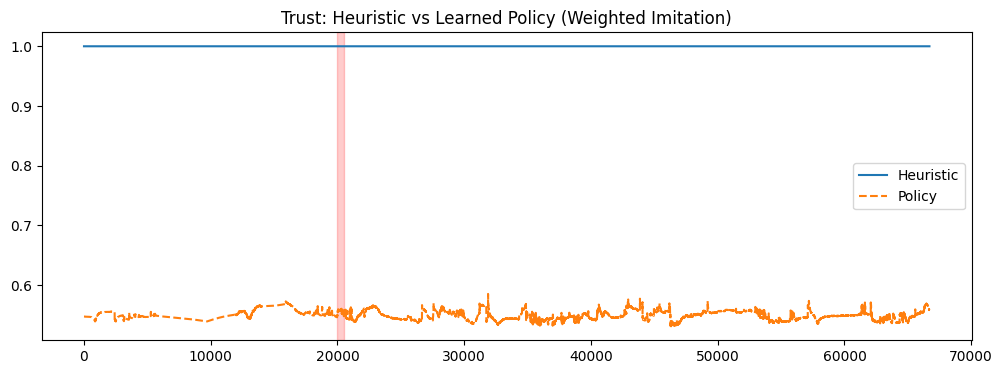

In [179]:
plt.figure(figsize=(12,4))

plt.plot(
    trust_teacher[:, faulty_neighbor].cpu(),
    label="Heuristic"
)

plt.plot(
    trust_policy[:, faulty_neighbor].detach().cpu(),
    label="Policy",
    linestyle="--"
)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Trust: Heuristic vs Learned Policy (Weighted Imitation)")
plt.show()


In [180]:
X_spatial_hat_policy = spatial_reconstruct_trust_weighted(
    X_fault_nb,
    fault_flags_t,
    nbr_idx_torch,
    nbr_dist_torch,
    trust_policy
)


In [181]:
print("Heuristic trust mean:", trust.mean().item())
print("Policy trust mean:", trust_policy.mean().item())


Heuristic trust mean: 0.25
Policy trust mean: 0.5514546036720276


# Reward based RL

In [182]:
policy = NeighborFaultClassifier()
optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)


In [183]:
for epoch in range(EPOCHS):

    total_loss = 0.0
    steps = 0
    trust_prev = None

    for t in range(FAULT_START, FAULT_END):

        if not fault_flags_t[t, sensor_idx]:
            continue

        state = build_neighbor_state(
            t,
            sensor_idx,
            X_fault,            # ✅ USE SINGLE-FAULT DATA
            X_temp_hat,
            fault_flags_t,
            nbr_idx_torch
        )

        p_fault = policy(state).squeeze()
        trust = 1.0 - p_fault
        trust = torch.clamp(trust, 0.0, 1.0)

        nbrs = nbr_idx_torch[sensor_idx]
        geo_w = 1.0 / (nbr_dist_torch[sensor_idx] + eps)
        w = geo_w * trust
        w = w / (w.sum() + eps)

        X_hat = torch.sum(w * X_fault[t, nbrs])   # ✅ SINGLE-FAULT DATA

        # --- losses ---
        L_rec = (X_hat - Y_true[t, sensor_idx]) ** 2

        temp_conf = torch.exp(
            -torch.abs(X_fault[t, sensor_idx] - X_temp_hat[t, sensor_idx])
        )

        L_dis = temp_conf * torch.mean(
            trust * torch.abs(X_fault[t, nbrs] - X_temp_hat[t, sensor_idx])
        )

        L_sparse = torch.mean(trust)

        closest = torch.argmin(nbr_dist_torch[sensor_idx])
        L_anchor = (1.0 - trust[closest])

        if trust_prev is not None:
            L_smooth = torch.mean((trust - trust_prev) ** 2)
        else:
            L_smooth = 0.0

        trust_prev = trust.detach()

        loss = (
            L_rec
            + 0.1 * L_dis
            + 0.01 * L_sparse
            + 0.1 * L_anchor
            + 0.05 * L_smooth
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        steps += 1

    print(f"Epoch {epoch+1:02d} | loss = {total_loss / (steps + eps):.6f}")


Epoch 01 | loss = 2.753463
Epoch 02 | loss = 1.649593
Epoch 03 | loss = 1.522556
Epoch 04 | loss = 1.488871
Epoch 05 | loss = 1.505955
Epoch 06 | loss = 1.499907
Epoch 07 | loss = 1.494573
Epoch 08 | loss = 1.484831
Epoch 09 | loss = 1.481629
Epoch 10 | loss = 1.477977
Epoch 11 | loss = 1.475676
Epoch 12 | loss = 1.476402
Epoch 13 | loss = 1.475645
Epoch 14 | loss = 1.476462
Epoch 15 | loss = 1.478946
Epoch 16 | loss = 1.480669
Epoch 17 | loss = 1.481634
Epoch 18 | loss = 1.486811
Epoch 19 | loss = 1.487355
Epoch 20 | loss = 1.488648
Epoch 21 | loss = 1.481479
Epoch 22 | loss = 1.488635
Epoch 23 | loss = 1.470346
Epoch 24 | loss = 1.488632
Epoch 25 | loss = 1.470914
Epoch 26 | loss = 1.488629
Epoch 27 | loss = 1.471471
Epoch 28 | loss = 1.488631
Epoch 29 | loss = 1.476602
Epoch 30 | loss = 1.488631


In [184]:
trust_cls = torch.ones_like(X_fault_nb)

with torch.no_grad():
    for t in range(T):

        if not fault_flags_t[t, sensor_idx]:
            continue

        state = build_neighbor_state(
            t,
            sensor_idx,
            X_fault_nb,
            X_temp_hat,
            fault_flags_t,
            nbr_idx_torch
        )

        p_fault = policy(state).squeeze()
        trust = 1.0 - p_fault
        trust = torch.clamp(trust, 0.0, 1.0)

        # hard anchor: force closest neighbor to be trusted
        score = trust / (nbr_dist_torch[sensor_idx] + 1e-6)
        anchor = torch.argmax(score)
        trust[anchor] = 1.0

        trust_cls[t, nbr_idx_torch[sensor_idx]] = trust

In [185]:
X_spatial_hat_cls = spatial_reconstruct_trust_weighted(
    X_fault_nb,
    fault_flags_t,
    nbr_idx_torch,
    nbr_dist_torch,
    trust_cls
)


In [186]:
rmse_cls = torch.sqrt(
    torch.mean(
        (X_spatial_hat_cls[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE (neighbor fault classifier):", rmse_cls.item())


RMSE (neighbor fault classifier): 6.873660564422607


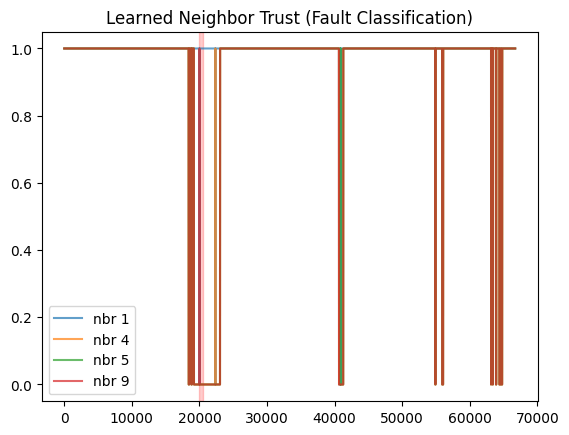

In [187]:
for n in nbr_idx[sensor_idx]:
    plt.plot(
        trust_cls[:, n].cpu(),
        label=f"nbr {n}",
        alpha=0.7
    )

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Learned Neighbor Trust (Fault Classification)")
plt.show()


In [133]:
# class NeighborTrustPolicy(nn.Module):
#     def __init__(self, K):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(5, 32),
#             nn.ReLU(),
#             nn.Linear(32, K)
#         )

#     def forward(self, state):
#         return torch.softmax(self.net(state), dim=-1)


In [134]:
# def reconstruction_loss(
#     X_hat,
#     Y_true,
#     mask_fault_window,
#     sensor_idx
# ):
#     """
#     Negative reward = MSE over fault window
#     """
#     return torch.mean(
#         (X_hat[mask_fault_window, sensor_idx]
#          - Y_true[mask_fault_window, sensor_idx]) ** 2
#     )


In [116]:
# def neighbor_disagreement_loss(
#     X_temp_hat,
#     X_spatial_hat,
#     trust,
#     fault_flags,
#     nbr_idx,
#     sensor_idx,
#     eps=1e-6
# ):
#     """
#     Penalize trusting neighbors that disagree with temporal model
#     Only active during fault window of target sensor
#     """
#     T = X_temp_hat.shape[0]
#     loss_terms = []

#     for t in range(T):
#         if not fault_flags[t, sensor_idx]:
#             continue

#         nbrs = nbr_idx[sensor_idx]  # (K,)

#         # disagreement of each neighbor with temporal belief
#         err = torch.abs(
#             X_spatial_hat[t, nbrs] - X_temp_hat[t, sensor_idx]
#         )  # (K,)

#         trust_w = trust[t, nbrs]    # (K,)

#         # penalize trusting high-error neighbors
#         loss_terms.append(
#             torch.mean(trust_w * err)
#         )

#     if len(loss_terms) == 0:
#         return torch.tensor(0.0, device=X_temp_hat.device)

#     return torch.mean(torch.stack(loss_terms))


In [117]:
# policy = TrustPolicy()
# optimizer = torch.optim.Adam(policy.parameters(), lr=1e-4)

# for epoch in range(30):

#     # ---- build state ----
#     state = build_trust_state(
#         X_fault,
#         X_temp_hat,
#         X_spatial_hat,
#         fault_flags_t,
#         trust_prev=torch.ones_like(X_fault),  # no teacher now
#         nbr_idx_torch=nbr_idx_torch
#     )

#     X_state = state.reshape(-1, 5)

#     # ---- policy trust ----
#     trust_rl = policy(X_state).reshape(T, N)
#     trust_rl = torch.clamp(trust_rl, 1e-6, 1.0)

#     # ---- spatial reconstruction ----
#     X_hat_rl = spatial_reconstruct_trust_weighted(
#         X_fault,
#         fault_flags_t,
#         nbr_idx_torch,
#         nbr_dist_torch,
#         trust_rl
#     )

#     penalty = neighbor_disagreement_loss(
#         X_temp_hat,
#         X_spatial_hat,
#         trust_rl,
#         fault_flags_t,
#         nbr_idx_torch,
#         sensor_idx
#     )

#     # ---- loss (negative reward) ----
#     loss = reconstruction_loss(
#         X_hat_rl,
#         Y_true,
#         mask_fault_window,
#         sensor_idx
#     ) + 0.1 * penalty

#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

#     print(f"Epoch {epoch+1:02d} | reconstruction MSE = {loss.item():.6f}")


In [118]:
# plt.figure(figsize=(12,4))
# plt.plot(
#     trust_rl[:, faulty_neighbor].detach().cpu().numpy(),
#     label="RL trust"
# )
# plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
# plt.legend()
# plt.title("Learned Trust (Reward-Based)")
# plt.show()


In [119]:
# rmse_rl = torch.sqrt(
#     reconstruction_loss(
#         X_hat_rl,
#         Y_true,
#         mask_fault_window,
#         sensor_idx
#     )
# )

# print("RMSE (RL trust):", rmse_rl.item())


In [120]:
# for n in nbr_idx[sensor_idx]:
#     if n == faulty_neighbor:
#         continue
#     plt.plot(
#         trust_rl[:, n].detach().cpu(),
#         alpha=0.6,
#         label=f"nbr {n}"
#     )

# plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
# plt.legend()
# plt.title("RL Trust — Healthy Neighbors")
# plt.show()


In [188]:
outside_fault = ~mask_fault_window

mean_trust_outside = trust_cls[outside_fault][:, nbr_idx[sensor_idx]].mean()

print("Mean trust outside fault:", mean_trust_outside.item())


Mean trust outside fault: 0.946484386920929


In [189]:
for n in nbr_idx[sensor_idx]:
    print(
        f"Neighbor {n} | "
        f"mean trust (fault window): "
        f"{trust_cls[mask_fault_window, n].mean().item():.3f}"
    )


Neighbor 1 | mean trust (fault window): 0.998
Neighbor 4 | mean trust (fault window): 0.000
Neighbor 5 | mean trust (fault window): 0.000
Neighbor 9 | mean trust (fault window): 0.002


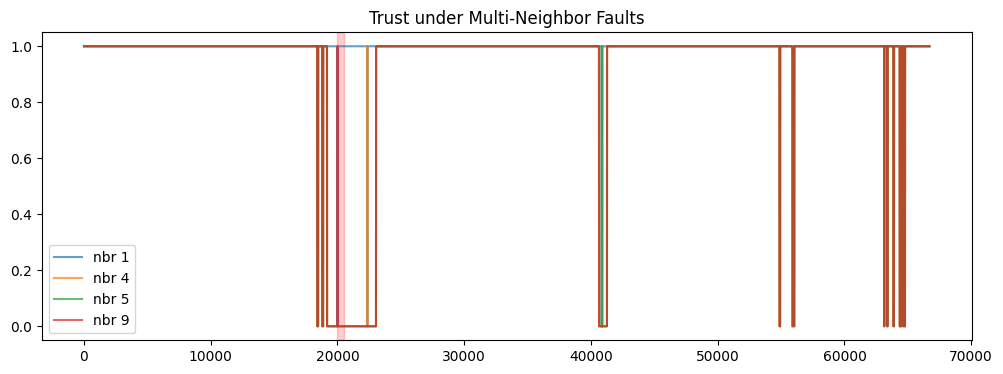

In [190]:
plt.figure(figsize=(12,4))
for n in neighbors_target:
    plt.plot(
        trust_cls[:, n].cpu(),
        label=f"nbr {n}",
        alpha=0.7
    )

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Trust under Multi-Neighbor Faults")
plt.show()
